In [56]:
using NCDatasets, Plots, Dates, Downloads, Statistics, DataFrames

In [57]:
# Load the NetCDF files from the specified directory
data_dir = "datafiles" # Directory to store downloaded NetCDF files
pat = r"^chesapeake_salinity_(\d{8})_t(\d{2})z_n(\d{3})\.nc$" # Regular expression pattern to match the desired NetCDF files
files = filter(f -> occursin(pat, f), readdir(data_dir)) # Filter files in the data directory that match the pattern

# Check if any files were found
if isempty(files)
    error("No files found matching chesapeake_salinity_YYYYMMDD_tCCz_nFFF.nc")
end

# Sort the files based on the date and time extracted from the filename
frames = NamedTuple[]
for f in files
    m = match(pat, f)
    ymd = m.captures[1]
    cyc = parse(Int, m.captures[2])   # cycle hour
    fh  = parse(Int, m.captures[3])   # forecast/nowcast hour
    dt = DateTime(ymd, dateformat"yyyymmdd") + Hour(cyc) + Hour(fh)
    push!(frames, (file="$data_dir/$f", dt=dt))
end
sort!(frames, by = x -> x.dt)

"""
Load surface salinity data from a NetCDF file.

Arguments:
- file: Path to the NetCDF file

Returns:
- lon_valid: Valid longitude values
- lat_valid: Valid latitude values
- salt_valid: Valid salinity values
"""
function load_surface_salinity(file)
    # Open the NetCDF file
    ds = NCDataset(file)

    # Extract latitude, longitude, and surface salinity data
    lon = ds["lon_rho"][:]
    lat = ds["lat_rho"][:]
    salt = ds["salt"][:,:,end,1]
    
    # Close the file
    close(ds)

    # Filter out invalid data (missing values, NaNs, and values greater than 100)
    valid_idx = .!ismissing.(salt) .&& .!isnan.(salt) .&& (salt .< 100)

    # Extract valid longitude, latitude, and salinity values
    if size(lon) == size(valid_idx) && size(lat) == size(valid_idx)
        lon_valid = lon[valid_idx]
        lat_valid = lat[valid_idx]
    elseif ndims(lon) == 1 && length(lon) == length(vec(valid_idx))
        lon2 = reshape(lon, size(valid_idx))
        lat2 = reshape(lat, size(valid_idx))
        lon_valid = lon2[valid_idx]
        lat_valid = lat2[valid_idx]
    else
        lon_valid = vec(lon)[vec(valid_idx)]
        lat_valid = vec(lat)[vec(valid_idx)]
    end

    return lon_valid, lat_valid, Float64.(salt[valid_idx])
end

load_surface_salinity

In [58]:
include("cb_variograms.jl")

Main.Variograms

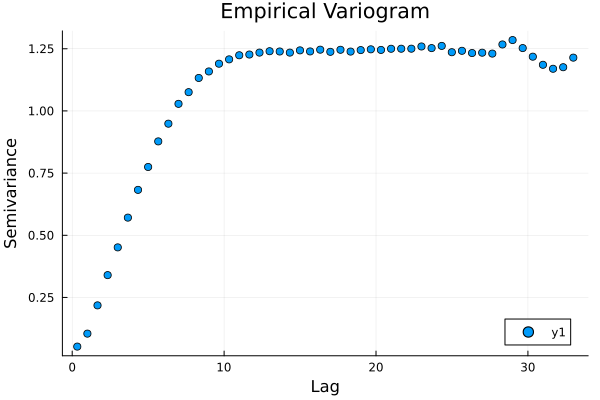

In [59]:
lat_min, lat_max = 37, 37.25
lon_min, lon_max = -76.25, -76.0

# Initialize salinity average variable
sal_avg = nothing

# Load surface salinity data from 1st frame
for i in 1:length(frames)
    file = frames[i].file

    lon, lat, salt = load_surface_salinity(file)

    roi = (lat .>= lat_min) .& (lat .<= lat_max) .& (lon .>= lon_min) .& (lon .<= lon_max)
    if i == 1
        sal_avg = salt[roi]
    else
        sal_avg = salt[roi] .* 1 ./i + sal_avg .* (i-1)./i
    end
end

#For using multiple files
lon_all = Float64[]
lat_all = Float64[]
salt_all = Float64[]
sal_diffs_all = Float64[]

all_bins = DataFrame[]

for fr in frames
    lon, lat, salt = load_surface_salinity(fr.file)

    roi = (lat .>= lat_min) .&
          (lat .<= lat_max) .&
          (lon .>= lon_min) .&
          (lon .<= lon_max)

    sal_diff = salt[roi] .- sal_avg

    bins = Variograms.empirical_spatial_variogram(
        lon[roi],
        lat[roi],
        sal_diff
    )

    push!(all_bins, bins)
end

lags = all_bins[1].h_mid

γ_emp = zeros(length(lags))

for b in all_bins
    γ_emp .+= b.variogram
end

γ_emp ./= length(all_bins)


# plot empirical variogram
scatter(lags, γ_emp, xlabel="Lag", ylabel="Semivariance", title="Empirical Variogram")

In [60]:
hp_models = []

for fr in frames
    lon, lat, salt = load_surface_salinity(fr.file)

    roi = (lat .>= lat_min) .&
          (lat .<= lat_max) .&
          (lon .>= lon_min) .&
          (lon .<= lon_max)

    # salinity anomaly relative to temporal mean field
    sal_diff = salt[roi] .- sal_avg

    hp_model = Variograms.hp_fit(
        lon[roi],
        lat[roi],
        sal_diff
    )

    push!(hp_models, hp_model)
end

using Statistics

param1 = [m[1] for m in hp_models]
param2 = [m[2] for m in hp_models]

median_param1 = median(param1)
median_param2 = median(param2)

hp_model = (median_param1, median_param2)

println(hp_model)

(1.1480020091204057, 4.286573630262789)


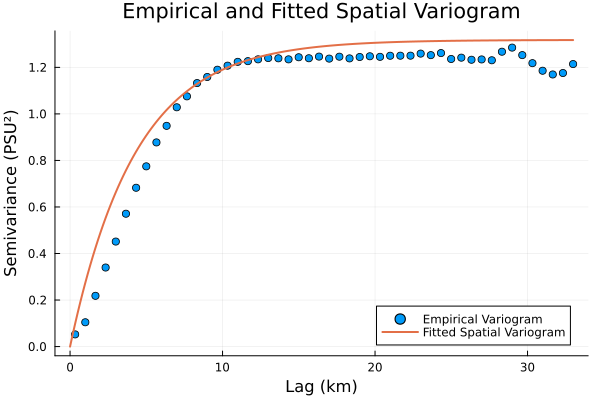

In [61]:
lag_grid = range(0, stop=maximum(lags), length=200)
γ_model = Variograms.spatio_variogram(lag_grid, hp_model)

scatter(lags, γ_emp,
    label="Empirical Variogram",
    xlabel="Lag (km)",
    ylabel="Semivariance (PSU²)",
    title="Empirical and Fitted Spatial Variogram"
)
plot!(lag_grid, γ_model, label="Fitted Spatial Variogram", lw=2)
savefig("spatial_variogram.png")
plot!()

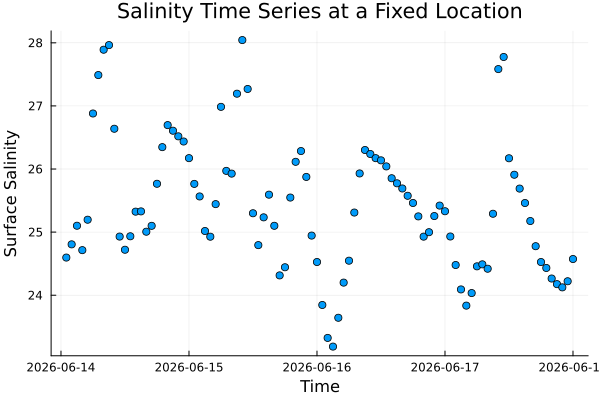

In [62]:
target_lon = (lon_min + lon_max) / 2 - 0.05
target_lat = (lat_min + lat_max) / 2 + 0.05

function nearest_grid_index(lon, lat, target_lon, target_lat)
    d2 = (lon .- target_lon).^2 .+ (lat .- target_lat).^2
    return argmin(d2)
end

lon0, lat0, salt0 = load_surface_salinity(frames[1].file)
idx = nearest_grid_index(lon0, lat0, target_lon, target_lat)

times = DateTime[]
salinity_ts = Float64[]

for fr in frames
    _, _, salt = load_surface_salinity(fr.file)
    val = salt[idx]
    push!(times, fr.dt)
    push!(salinity_ts,
        ismissing(val) || isnan(val) || val >= 100 ? NaN : Float64(val))
end

plot(times, salinity_ts,
    seriestype = :scatter,
    xlabel = "Time",
    ylabel = "Surface Salinity",
    title = "Salinity Time Series at a Fixed Location",
    legend = false
)

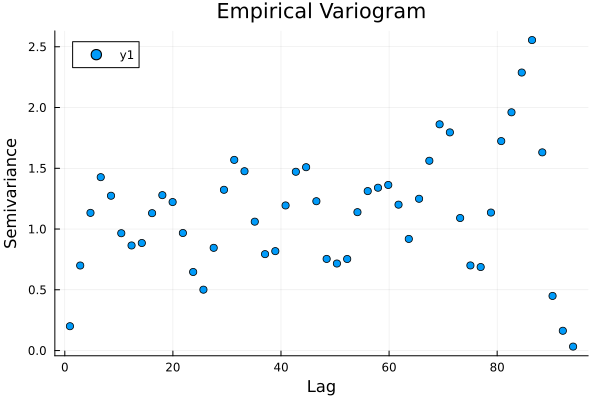

In [63]:
# compute empirical variogram (adjust nbins/maxlag as needed)
bins = Variograms.empirical_temporal_variogram(times, salinity_ts)

lags = bins.h_mid
γ_emp = bins.variogram

# plot empirical variogram
scatter(lags, γ_emp, xlabel="Lag", ylabel="Semivariance", title="Empirical Variogram")

In [64]:
hp_temp_model = Variograms.hp_fit(times, salinity_ts)
println(hp_temp_model)

(1.0, 0.011326419301579278, 0.4691997885388099)


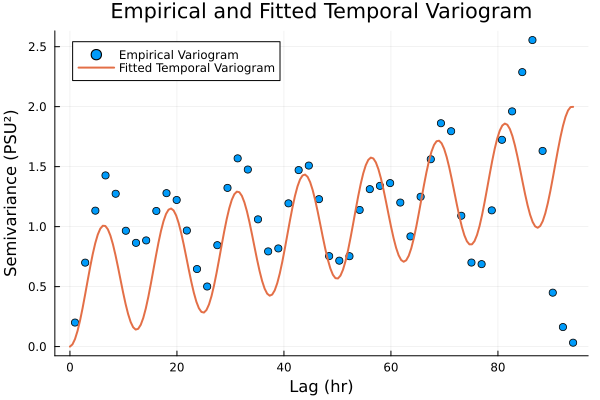

In [65]:
lag_grid = range(0, stop=maximum(lags), length=200)
γ_model = Variograms.temporal_variogram(lag_grid, hp_temp_model)

scatter(lags, γ_emp,
    label="Empirical Variogram",
    xlabel="Lag (hr)",
    ylabel="Semivariance (PSU²)",
    title="Empirical and Fitted Temporal Variogram"
)
plot!(lag_grid, γ_model, label="Fitted Temporal Variogram", lw=2)
savefig("temporal_variogram.png")
plot!()
